In [1]:
def _kf_apply_doc_styles() -> None:
    from pathlib import Path
    import kfactory.utilities
    import kfactory.widgets.interactive

    _lyp = Path('/home/runner/work/kfactory/kfactory/docs/source-built/_static/doc_styles.lyp')
    if not _lyp.is_file():
        return
    _original = kfactory.utilities.as_png_data

    def _styled_as_png_data(c, layer_properties=None, **kwargs):
        return _original(c, layer_properties=layer_properties or str(_lyp), **kwargs)

    kfactory.utilities.as_png_data = _styled_as_png_data
    kfactory.widgets.interactive.as_png_data = _styled_as_png_data


_kf_apply_doc_styles()


# KCLayout — layout context and PDK

`KCLayout` is the root container for everything kfactory manages: layers, cells,
factories, enclosures, and cross-sections. It wraps a KLayout `kdb.Layout` object
and adds kfactory-specific tracking on top.

Key facts:

- `kf.kcl` is the **default, module-level** `KCLayout`. Most single-PDK workflows
  only ever use this one object.
- You can create additional `KCLayout` instances to model a second PDK or a cell
  library — cells from any layout can be instantiated inside any other.
- The **`dbu`** attribute controls the database unit (grid size in µm).
  The default is `0.001` (1 nm grid). Changing it on an empty layout is safe;
  changing it after cells have been added causes geometry to shift.
- The **`factories`** dict maps string names to decorated cell functions registered
  on this layout. Calling `kcl.factories["straight"](...)` is equivalent to calling
  the underlying function directly.

## Setup: layers

Each notebook defines its own layer set. The `kf.kcl.infos = L` line makes the
default layout aware of these layers so helpers like `find_layer` work.

In [2]:
import kfactory as kf


class LAYER(kf.LayerInfos):
    WG: kf.kdb.LayerInfo = kf.kdb.LayerInfo(1, 0)
    WGEX: kf.kdb.LayerInfo = kf.kdb.LayerInfo(2, 0)
    CLAD: kf.kdb.LayerInfo = kf.kdb.LayerInfo(4, 0)
    FLOORPLAN: kf.kdb.LayerInfo = kf.kdb.LayerInfo(10, 0)


L = LAYER()
kf.kcl.infos = L

## The default layout: `kf.kcl`

`kf.kcl` is always available after `import kfactory as kf`. It holds the global
namespace of cells.

In [3]:
# Name and grid size of the default layout
print(f"name : {kf.kcl.name}")
print(f"dbu  : {kf.kcl.dbu} µm  ({kf.kcl.dbu * 1000:.0f} nm grid)")

name : DEFAULT
dbu  : 0.001 µm  (1 nm grid)


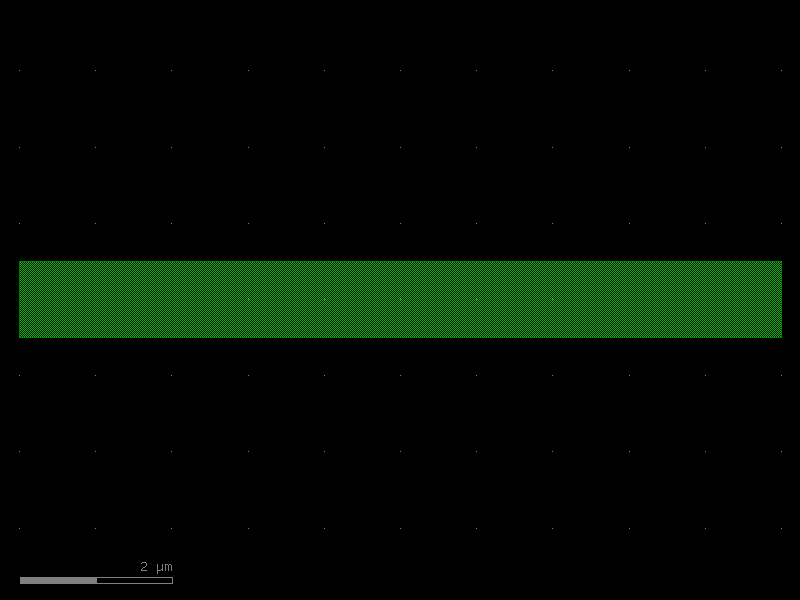

In [4]:
# Create a straight waveguide in the default layout
s = kf.cells.straight.straight(width=1, length=10, layer=L.WG)
s

In [5]:
# The layout now contains one registered KCell
kf.kcl.kcells

KCells(DEFAULT, n=0)

## Creating a second layout (second PDK)

Pass a name string to `KCLayout(...)`. You can also set a different `dbu` to
simulate a PDK with a coarser grid (e.g. 5 nm instead of 1 nm).

In [6]:
kcl2 = kf.KCLayout("DEMO_PDK", infos=LAYER)
kcl2.dbu = 0.005  # 5 nm grid
print(f"name : {kcl2.name}")
print(f"dbu  : {kcl2.dbu} µm  ({kcl2.dbu * 1000:.0f} nm grid)")

name : DEMO_PDK
dbu  : 0.005 µm  (5 nm grid)


In [7]:
# The new layout starts empty
kcl2.kcells

KCells(DEMO_PDK, n=0)

## Registering a factory on a custom layout

`straight_dbu_factory` returns a cell function that is pre-bound to `kcl2`.
After registration, the factory is accessible by name via `kcl2.factories`.

In [8]:
sf2 = kf.factories.straight.straight_dbu_factory(kcl=kcl2)

# Call the factory directly …
s2 = kcl2.factories["straight"](length=10_000, width=200, layer=L.WG)
s2.settings

KCellSettings(width=200, length=10000, layer=WG (1/0), enclosure=None)

## DBU vs µm dimensions across layouts

The same physical width (1 µm) occupies different numbers of database units
depending on the grid size. The `dbbox()` method always returns µm regardless
of `dbu`.

In [9]:
# Default layout: 1 nm grid  → 1 µm = 1000 dbu
print("--- default kcl (1 nm grid) ---")
print(f"  height dbu : {s.bbox().height()}")
print(f"  height µm  : {s.dbbox().height()}")
print(f"  width  dbu : {s.bbox().width()}")
print(f"  width  µm  : {s.dbbox().width()}")

# DEMO_PDK: 5 nm grid  → 1 µm = 200 dbu
print("--- DEMO_PDK (5 nm grid) ---")
print(f"  height dbu : {s2.bbox().height()}")
print(f"  height µm  : {s2.dbbox().height()}")
print(f"  width  dbu : {s2.bbox().width()}")
print(f"  width  µm  : {s2.dbbox().width()}")

--- default kcl (1 nm grid) ---
  height dbu : 1000
  height µm  : 1.0
  width  dbu : 10000
  width  µm  : 10.0
--- DEMO_PDK (5 nm grid) ---
  height dbu : 200
  height µm  : 1.0
  width  dbu : 10000
  width  µm  : 50.0


Port widths follow the same rule — `ports.print()` shows DBU values by default;
pass `unit="um"` to see physical (µm) values instead.

In [10]:
print("=== ports in DBU ===")
s.ports.print()
s2.ports.print()

print("\n=== ports in µm ===")
s.ports.print(unit="um")
s2.ports.print(unit="um")

=== ports in DBU ===


┏━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━┓
┃ Name ┃ Width ┃ Layer    ┃ Type    ┃ X      ┃ Y ┃ Angle ┃ Mirror ┃ Info ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━┩
│ o1   │ 1_000 │ WG (1/0) │ optical │ 0      │ 0 │ 2     │ False  │ {}   │
├──────┼───────┼──────────┼─────────┼────────┼───┼───────┼────────┼──────┤
│ o2   │ 1_000 │ WG (1/0) │ optical │ 10_000 │ 0 │ 0     │ False  │ {}   │
└──────┴───────┴──────────┴─────────┴────────┴───┴───────┴────────┴──────┘

┏━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━┓
┃ Name ┃ Width ┃ Layer    ┃ Type    ┃ X      ┃ Y ┃ Angle ┃ Mirror ┃ Info ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━┩
│ o1   │ 200   │ WG (1/0) │ optical │ 0      │ 0 │ 2     │ False  │ {}   │
├──────┼───────┼──────────┼─────────┼────────┼───┼───────┼────────┼──────┤
│ o2   │ 200   │ WG (1/0) │ optical │ 10_000 │ 0 │ 0     │ False  │ {}   │
└──────┴───────┴──────────┴─────────┴────────┴───┴───────┴────────┴──────┘


=== ports in µm ===


┏━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━┓
┃ Name ┃ Width ┃ Layer    ┃ Type    ┃ X    ┃ Y   ┃ Angle ┃ Mirror ┃ Info ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━┩
│ o1   │ 1.0   │ WG (1/0) │ optical │ 0.0  │ 0.0 │ 180.0 │ False  │ {}   │
├──────┼───────┼──────────┼─────────┼──────┼─────┼───────┼────────┼──────┤
│ o2   │ 1.0   │ WG (1/0) │ optical │ 10.0 │ 0.0 │ 0.0   │ False  │ {}   │
└──────┴───────┴──────────┴─────────┴──────┴─────┴───────┴────────┴──────┘

┏━━━━━━┳━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┳━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━┓
┃ Name ┃ Width ┃ Layer    ┃ Type    ┃ X    ┃ Y   ┃ Angle ┃ Mirror ┃ Info ┃
┡━━━━━━╇━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━╇━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━┩
│ o1   │ 1.0   │ WG (1/0) │ optical │ 0.0  │ 0.0 │ 180.0 │ False  │ {}   │
├──────┼───────┼──────────┼─────────┼──────┼─────┼───────┼────────┼──────┤
│ o2   │ 1.0   │ WG (1/0) │ optical │ 50.0 │ 0.0 │ 0.0   │ False  │ {}   │
└──────┴───────┴──────────┴─────────┴──────┴─────┴───────┴────────┴──────┘

## Mixing cells from different layouts

Cells from any `KCLayout` can be instantiated inside a cell belonging to another
layout. kfactory copies the referenced cell's geometry transparently.

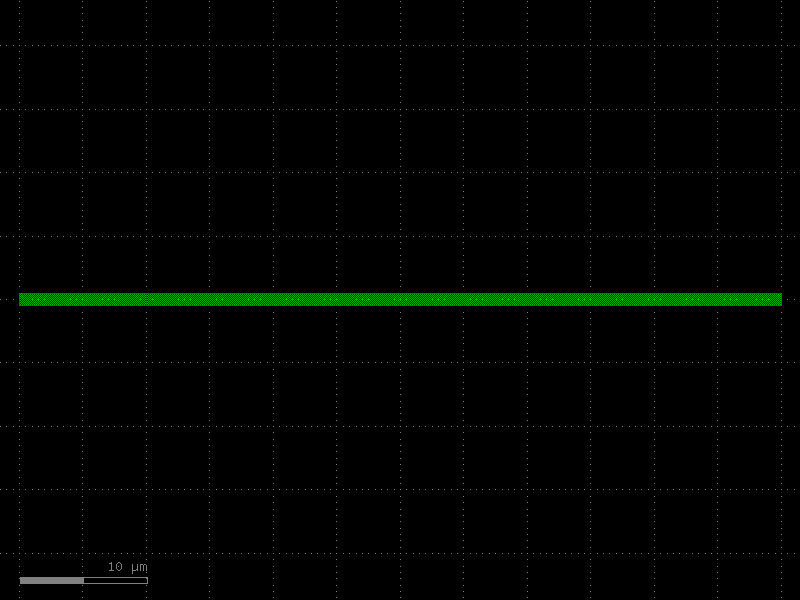

In [11]:
c = kf.kcl.kcell("mixed_pdks")
si_default = c << s  # instance of the 1 nm-grid straight
si_demo = c << s2  # instance of the 5 nm-grid straight

# Connect port o1 of the demo cell to port o2 of the default cell
si_demo.connect("o1", si_default, "o2")
c

## Saving and loading GDS files

`KCLayout.write()` serialises the layout (and its cell metadata) to a GDS/OASIS
file. `KCLayout.read()` loads it back.

In [12]:
import tempfile
from pathlib import Path

with tempfile.TemporaryDirectory() as tmp:
    gds_path = Path(tmp) / "demo.gds"
    kf.kcl.write(gds_path)
    print(f"written: {gds_path.stat().st_size} bytes")

    # Load into a fresh layout to verify round-trip
    kcl3 = kf.KCLayout("LOADED")
    kcl3.read(gds_path, register_cells=True)
    print(f"cells read back: {list(kcl3.kcells.keys())[:5]}")

written: 1332 bytes
cells read back: [1, 0, 2]


## Key attributes at a glance

| Attribute / method | Type | Description |
|---|---|---|
| `kcl.name` | `str` | Layout identifier |
| `kcl.dbu` | `float` | Grid size in µm (e.g. `0.001` = 1 nm) |
| `kcl.layout` | `kdb.Layout` | Underlying KLayout object |
| `kcl.kcells` | `KCells` | Mapping of cell index → `KCell` |
| `kcl.infos` | `LayerInfos` | Layer definitions |
| `kcl.factories` | `Factories` | Registered cell-factory functions |
| `kcl.kcell(name)` | `KCell` | Create a new, empty cell |
| `kcl.read(path)` | — | Load GDS/OASIS file |
| `kcl.write(path)` | — | Save GDS/OASIS file |

## See Also

| Topic | Where |
|-------|-------|
| Building a full PDK with a custom KCLayout | [PDK: Creating a PDK](../pdk/creating_pdk.py) |
| Session save/load to speed up rebuilds | [Utilities: Session Cache](../utilities/session_cache.py) |
| Layer definitions and LayerInfos | [Core Concepts: Layers](layers.py) |